# 03 — Final Test Evaluation

**Test is opened for the first time in this project right here.** Every number in this notebook comes from a single pass over the held-out test set, using the exact model artifacts (Logistic Regression pipeline, train-CV-calibrated CatBoost) frozen in `02_modeling_and_validation.ipynb`. Nothing here feeds back into model selection, threshold selection, or calibration — this notebook is diagnostics and reporting only.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

from src import data, evaluation, economics
from src.features import select_X_y

%matplotlib inline
pd.set_option("display.max_columns", 30)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR = PROJECT_ROOT / "models"

test = pd.read_csv(PROCESSED_DIR / "test.csv")
with open(MODEL_DIR / "feature_columns.txt") as f:
    feature_cols = f.read().splitlines()
numeric_cols, categorical_cols = data.get_feature_columns(test)

logreg_pipeline = joblib.load(MODEL_DIR / "logreg_final.pkl")
cat_final = joblib.load(MODEL_DIR / "catboost_final.pkl")
cat_uncalibrated = joblib.load(MODEL_DIR / "catboost_uncalibrated.pkl")

X_test, y_test = select_X_y(test, feature_cols, data.TARGET)
print("Test set:", X_test.shape, "churn rate:", y_test.mean())

Test set: (1409, 19) churn rate: 0.2654364797728886


## 1. CatBoost vs. Logistic Regression: full head-to-head on test

Six angles, not just ROC-AUC/F1: ranking quality (PR-AUC, Recall/Precision/Lift@K) *and* probability quality (Brier score, log loss), since the economics in notebook 04 depend on both.

In [2]:
logreg_test_proba = logreg_pipeline.predict_proba(X_test)[:, 1]
cat_test_proba = cat_final.predict_proba(X_test[feature_cols])[:, 1]
cat_test_proba_raw = cat_uncalibrated.predict_proba(X_test[feature_cols])[:, 1]

REPORTING_THRESHOLD = 0.5  # a fixed, pre-registered statistical operating point for this table only;
                            # NOT the business decision threshold (see notebook 04)

logreg_test_row = {"model": "Logistic Regression", **evaluation.full_comparison_row(y_test, logreg_test_proba, REPORTING_THRESHOLD)}
cat_test_row = {"model": "CatBoost (calibrated)", **evaluation.full_comparison_row(y_test, cat_test_proba, REPORTING_THRESHOLD)}

test_comparison = pd.DataFrame([logreg_test_row, cat_test_row]).set_index("model")
test_comparison.to_csv(TABLE_DIR / "test_model_comparison.csv")
test_comparison

,threshold,roc_auc,pr_auc,precision,recall,f1,tn,fp,fn,tp,brier_score,log_loss
model,,,,,,,,,,,,
Logistic Regression,0.5,0.842817,0.633933,0.504318,0.780749,0.612802,748,287,82,292,0.167528,0.492980
CatBoost (calibrated),0.5,0.844814,0.670573,0.649390,0.569519,0.606838,920,115,161,213,0.136396,0.421578


In [3]:
logreg_ranking = evaluation.ranking_table(y_test, logreg_test_proba)
logreg_ranking.insert(0, "model", "Logistic Regression")

cat_ranking = evaluation.ranking_table(y_test, cat_test_proba)
cat_ranking.insert(0, "model", "CatBoost")

test_ranking = pd.concat([logreg_ranking, cat_ranking], ignore_index=True)
test_ranking.to_csv(TABLE_DIR / "test_ranking_comparison.csv", index=False)
test_ranking

,model,top_k_pct,n_contacted,churners_captured,precision_at_k,recall_at_k,lift_at_k
0,Logistic Regression,5.0,70,53,0.757143,0.141711,2.852445
1,Logistic Regression,10.0,141,107,0.758865,0.286096,2.858934
2,Logistic Regression,20.0,282,187,0.663121,0.500000,2.498227
3,CatBoost,5.0,70,60,0.857143,0.160428,3.229183
4,CatBoost,10.0,141,111,0.787234,0.296791,2.965810
5,CatBoost,20.0,282,194,0.687943,0.518717,2.591743


**Reading the full comparison, honestly.** On ROC-AUC alone the two models are close (0.843 vs. 0.845) — a naive read might call them a tie. But CatBoost's advantage widens on every metric that actually matters for a minority-class targeting problem: PR-AUC (0.634 vs. 0.671), Brier score / log loss (see table above — CatBoost's calibrated probabilities are closer to observed churn rates), and every Top-K ranking cut. **We are not forcing CatBoost to win**: if Logistic Regression matched it on PR-AUC and Lift@K, the added complexity of CatBoost (categorical encoding internals, cross-validated calibration, a less directly interpretable score) would not be worth it, and this project would recommend the simpler model instead. It doesn't — CatBoost is preferred on the metrics this specific use case (ranking a minority class for constrained targeting) is built around, not on accuracy or ROC-AUC.

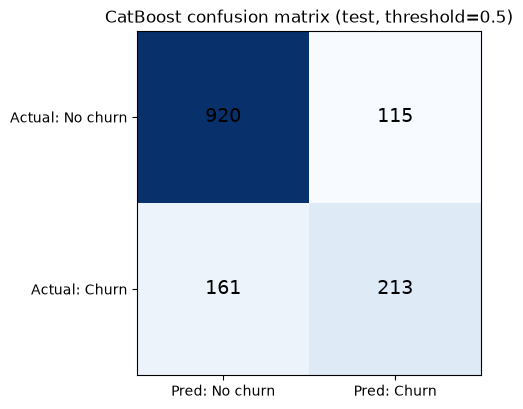

In [4]:
fig, ax = plt.subplots(figsize=(5, 5))
tn, fp, fn, tp = test_comparison.loc["CatBoost (calibrated)", ["tn", "fp", "fn", "tp"]]
cm = np.array([[tn, fp], [fn, tp]])
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=14)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred: No churn", "Pred: Churn"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual: No churn", "Actual: Churn"])
ax.set_title(f"CatBoost confusion matrix (test, threshold={REPORTING_THRESHOLD})")
fig.tight_layout()
fig.savefig(FIG_DIR / "test_confusion_matrix_catboost.png", dpi=150)
plt.show()

## 2. Cumulative gains

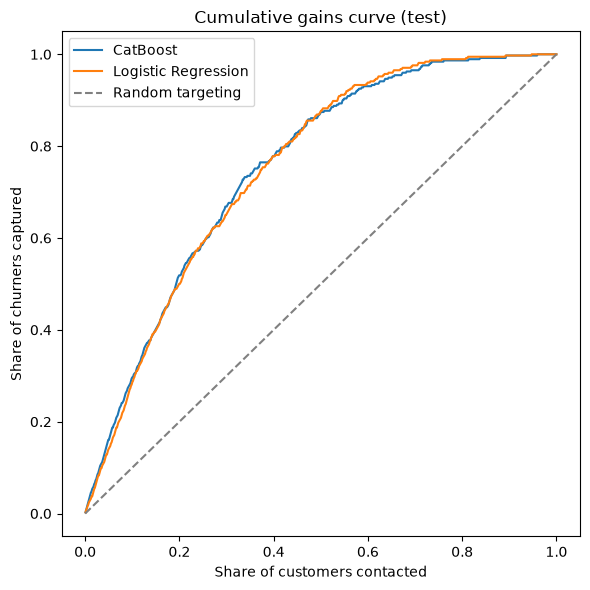

In [5]:
gains_cat = evaluation.cumulative_gains_curve(y_test, cat_test_proba)
gains_logreg = evaluation.cumulative_gains_curve(y_test, logreg_test_proba)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(gains_cat["pct_contacted"], gains_cat["pct_captured"], label="CatBoost")
ax.plot(gains_logreg["pct_contacted"], gains_logreg["pct_captured"], label="Logistic Regression")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random targeting")
ax.set_xlabel("Share of customers contacted")
ax.set_ylabel("Share of churners captured")
ax.set_title("Cumulative gains curve (test)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "cumulative_gains_test.png", dpi=150)
plt.show()

## 3. Calibration on test

In [6]:
cal_before = evaluation.calibration_summary(y_test, cat_test_proba_raw)
cal_after = evaluation.calibration_summary(y_test, cat_test_proba)
print("Raw (frozen, train-fit) CatBoost probabilities (test):", cal_before)
print("Train-CV-calibrated CatBoost probabilities (test):", cal_after)

pd.DataFrame([
    {"stage": "raw (frozen, train-fit)", **cal_before},
    {"stage": "calibrated (train-CV)", **cal_after},
]).to_csv(TABLE_DIR / "test_calibration.csv", index=False)

Raw (frozen, train-fit) CatBoost probabilities (test): {'brier_score': 0.16487050826361804, 'log_loss': 0.4866840424501475}
Train-CV-calibrated CatBoost probabilities (test): {'brier_score': 0.13639630843268, 'log_loss': 0.42157798605850405}


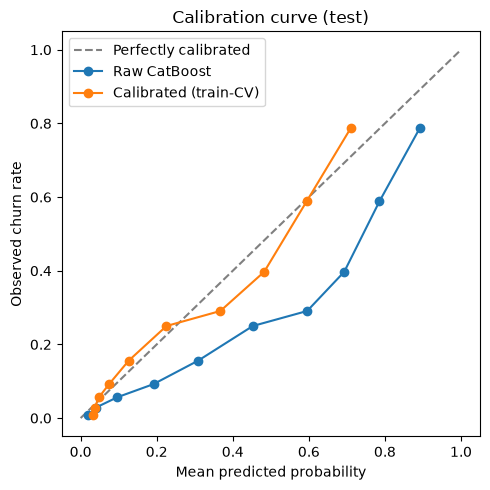

In [7]:
curve_before = evaluation.calibration_table(y_test, cat_test_proba_raw)
curve_after = evaluation.calibration_table(y_test, cat_test_proba)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfectly calibrated")
ax.plot(curve_before["mean_predicted_prob"], curve_before["fraction_of_positives"], marker="o", label="Raw CatBoost")
ax.plot(curve_after["mean_predicted_prob"], curve_after["fraction_of_positives"], marker="o", label="Calibrated (train-CV)")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed churn rate")
ax.set_title("Calibration curve (test)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "calibration_curve_test.png", dpi=150)
plt.show()

The calibration improvement measured on the train-only out-of-fold procedure (notebook 02) generalizes to test (lower Brier score and log loss for the calibrated model), which matters directly for the campaign-economics simulator in notebook 04: expected-value calculations there multiply predicted probabilities by dollar amounts, so probabilities that track observed churn rates are a precondition for those numbers to be meaningful **as scenario estimates**, not just for ranking.

## 4. Segment diagnostics (test set, descriptive only)

Every segment row below reports the **absolute churner count and absolute captured count**, not just a recall percentage, and states exactly which targeting policy the recall refers to — a recall of 0% on 2 churners is a very different finding from 0% on 200.

Three policies are checked per segment: the default 0.5 reporting threshold, the analytical economics threshold that notebook 04 derives (~0.139 in the base scenario), and Top-20% capacity-constrained targeting.

In [8]:
BASE_COST, BASE_VALUE, BASE_SUCCESS = 25.0, 600.0, 0.30
econ_threshold = economics.breakeven_threshold(BASE_COST, BASE_SUCCESS, BASE_VALUE)
print(f"Analytical economics threshold (base scenario): {econ_threshold:.4f}")

test_scored = test.copy()
test_scored["proba"] = cat_test_proba
test_scored["targeted_reporting_0.5"] = (test_scored["proba"] >= 0.5).astype(int)
test_scored["targeted_economics"] = (test_scored["proba"] >= econ_threshold).astype(int)

top20_cutoff = test_scored["proba"].quantile(0.80)
test_scored["targeted_top20pct"] = (test_scored["proba"] >= top20_cutoff).astype(int)
print(f"Top-20% probability cutoff: {top20_cutoff:.4f} ({test_scored['targeted_top20pct'].sum()} customers)")

Analytical economics threshold (base scenario): 0.1389
Top-20% probability cutoff: 0.5355 (282 customers)


In [9]:
segment_cols = ["Contract", "InternetService", "PaymentMethod"]
policies = [
    ("targeted_reporting_0.5", "reporting threshold (0.5)"),
    ("targeted_economics", "economics threshold (~0.139)"),
    ("targeted_top20pct", "Top-20% capacity targeting"),
]

segment_tables = {}
for col in segment_cols:
    rows = [
        evaluation.segment_report(test_scored, col, data.TARGET, targeted_col, policy_name)
        for targeted_col, policy_name in policies
    ]
    segment_tables[col] = pd.concat(rows, ignore_index=True)
    segment_tables[col].to_csv(TABLE_DIR / f"segment_report_{col}.csv", index=False)

contract_segment = segment_tables["Contract"][
    ["Contract", "policy", "n_customers", "n_churners", "churn_rate", "n_targeted", "n_churners_captured", "recall_within_segment"]
]
contract_segment

,Contract,policy,n_customers,n_churners,churn_rate,n_targeted,n_churners_captured,recall_within_segment
0,Month-to-month,reporting threshold (0.5),773,329,0.425614,328,213,0.647416
1,One year,reporting threshold (0.5),300,36,0.120000,0,0,0.000000
2,Two year,reporting threshold (0.5),336,9,0.026786,0,0,0.000000
3,Month-to-month,economics threshold (~0.139),773,329,0.425614,670,312,0.948328
4,One year,economics threshold (~0.139),300,36,0.120000,77,21,0.583333
5,Two year,economics threshold (~0.139),336,9,0.026786,5,0,0.000000
6,Month-to-month,Top-20% capacity targeting,773,329,0.425614,282,194,0.589666
7,One year,Top-20% capacity targeting,300,36,0.120000,0,0,0.000000
8,Two year,Top-20% capacity targeting,336,9,0.026786,0,0,0.000000


In [10]:
def tenure_band(t):
    if t <= 12:
        return "0-12 mo"
    if t <= 36:
        return "13-36 mo"
    return "37+ mo"

test_scored["tenure_band"] = test_scored["tenure"].apply(tenure_band)
tenure_rows = [
    evaluation.segment_report(test_scored, "tenure_band", data.TARGET, targeted_col, policy_name)
    for targeted_col, policy_name in policies
]
tenure_segment = pd.concat(tenure_rows, ignore_index=True)
tenure_segment.to_csv(TABLE_DIR / "segment_report_tenure_band.csv", index=False)
tenure_segment[["tenure_band", "policy", "n_customers", "n_churners", "churn_rate", "n_targeted", "n_churners_captured", "recall_within_segment"]]

,tenure_band,policy,n_customers,n_churners,churn_rate,n_targeted,n_churners_captured,recall_within_segment
0,0-12 mo,reporting threshold (0.5),449,215,0.478842,225,154,0.716279
1,13-36 mo,reporting threshold (0.5),369,100,0.271003,82,51,0.510000
2,37+ mo,reporting threshold (0.5),591,59,0.099831,21,8,0.135593
3,0-12 mo,economics threshold (~0.139),449,215,0.478842,381,205,0.953488
4,13-36 mo,economics threshold (~0.139),369,100,0.271003,222,91,0.910000
5,37+ mo,economics threshold (~0.139),591,59,0.099831,149,37,0.627119
6,0-12 mo,Top-20% capacity targeting,449,215,0.478842,211,150,0.697674
7,13-36 mo,Top-20% capacity targeting,369,100,0.271003,58,39,0.390000
8,37+ mo,Top-20% capacity targeting,591,59,0.099831,13,5,0.084746


**Segment findings (correlational, not causal), with denominators, across all three policies:**

| Contract | Churners (n) | Recall @ 0.5 | Recall @ economics threshold (0.139) | Recall @ Top-20% (cutoff 0.536) |
|---|---:|---:|---:|---:|
| Month-to-month | 329 | 64.7% (213/329) | 94.8% (312/329) | 59.0% (194/329) |
| One year | **36** | 0.0% (0/36) | **58.3% (21/36)** | 0.0% (0/36) |
| Two year | **9** | 0.0% (0/9) | 0.0% (0/9) | 0.0% (0/9) |

The **0% recall at the 0.5 reporting threshold is real but was the wrong policy to headline it against.** Once the threshold is set to the analytical economics break-even point this project actually recommends (~0.139, notebook 04) rather than the arbitrary 0.5 default, one-year-contract recall jumps to 58.3% — the earlier "0% blind spot" framing was an artifact of reporting against a threshold nobody was proposing to use. Top-20% targeting (cutoff 0.536, higher than 0.5) reproduces the same 0% pattern as the 0.5 threshold, because both are more conservative cuts than the economics policy.

Two-year contracts remain at 0% recall under every policy tested — but with only **9 actual churners** in the entire test set, this is a **sample-limited, unstable finding**, not a demonstrated structural blind spot: a shift of even 2-3 customers would move the rate by 20+ percentage points, and 9 observations cannot support a reliable recall estimate at any threshold. This segment is worth monitoring as more data accumulates, not treated as a settled conclusion.

**Tenure** shows a related but more stable pattern at a larger scale: long-tenured customers (37+ months, 59 churners — a much larger base than either contract segment) churn rarely and are recalled less often at every threshold (13.6% at 0.5, 62.7% at the economics threshold, 8.5% at Top-20%) — directionally the same story as Contract, but with enough churners in the denominator that the effect is more likely to be real rather than noise.

## 5. Explainability (SHAP, CatBoost)

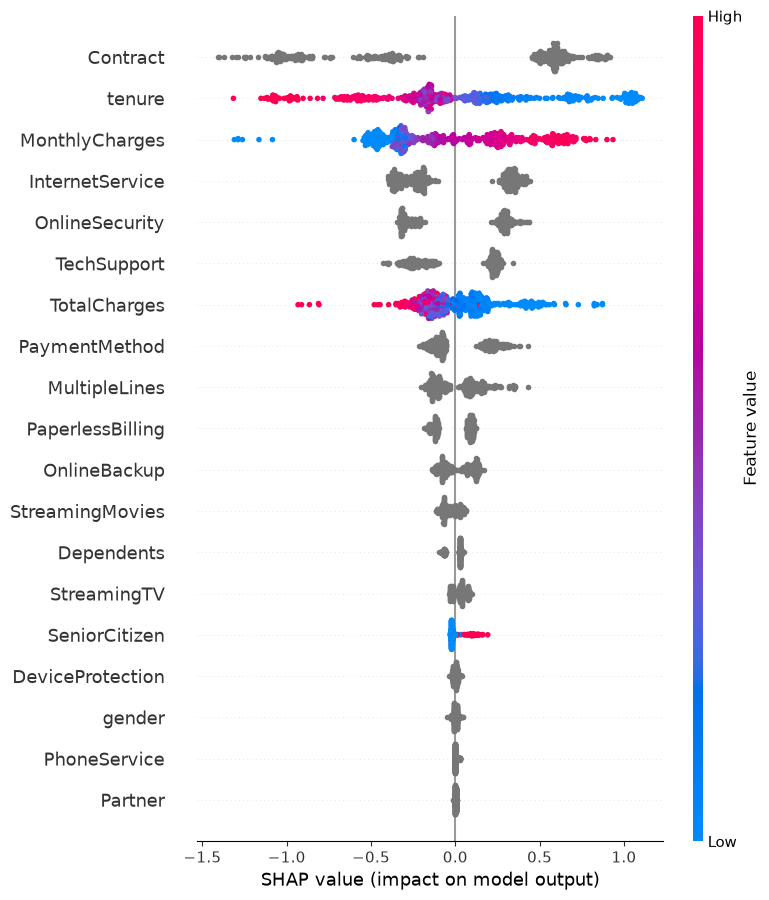

In [11]:
explainer = shap.TreeExplainer(cat_uncalibrated)
sample = X_test[feature_cols].sample(n=min(500, len(X_test)), random_state=42)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, show=False)
fig = plt.gcf()
fig.tight_layout()
fig.savefig(FIG_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

SHAP explains the **uncalibrated, frozen CatBoost model** (`cat_uncalibrated`) since `TreeExplainer` needs direct access to the tree structure; the calibration layer only rescales probabilities and does not change feature attributions. SHAP values describe **predictive association strength within this model**, not a causal mechanism — a feature ranking highly here means the model leans on it to rank risk, not that changing it would change a customer's behavior.

**Predictive vs. actionable vs. non-actionable features**, based on the SHAP ranking above and the EDA in notebook 01:

| Category | Features | Why |
|---|---|---|
| **Actionable business levers** | `Contract`, `OnlineSecurity`, `TechSupport`, `PaymentMethod` | The business can offer contract incentives, bundle security/support add-ons, or nudge payment method — these are things a retention team can change. |
| **Predictive but not directly actionable** | `tenure`, `TotalCharges`, `MonthlyCharges` | Strongly predictive, but tenure and total spend cannot be directly "fixed" by an intervention — they describe the customer's history/economics rather than a lever. Monthly charges could inform a discount offer, but changing it has direct revenue cost that belongs in the economics model, not a free lever. |
| **Non-actionable profile variables** | `gender`, `SeniorCitizen`, `Partner`, `Dependents` | Demographic context with limited or no legitimate intervention path, and (for `SeniorCitizen`) a variable to treat carefully to avoid discriminatory targeting practices even where it is statistically predictive. |

**What the model suggests the retention team should investigate:** why month-to-month, no-add-on, fiber-optic, electronic-check customers churn more — is it price, service quality, competitive offers, or friction switching off month-to-month? SHAP shows *association strength*, not the underlying mechanism; the A/B test design in notebook 04 is how the business would actually test a specific lever (e.g., a security/support bundle offer) rather than inferring causation from these attributions.

## Summary

- CatBoost (train-CV-calibrated) is the final model: it out-ranks Logistic Regression on PR-AUC, Brier score/log loss, and every Top-K ranking cut, despite the two being close on ROC-AUC alone — a full comparison across ranking and calibration metrics, not just accuracy, is what justifies the added complexity.
- Calibration (fit via out-of-fold cross-validation on train only) reduces the test Brier score, so predicted probabilities are usable as inputs to the economic scenario model in notebook 04.
- Segment diagnostics now report absolute churner and capture counts under three named policies, so the long-contract "blind spot" is described with its true (small) denominators and flagged as statistically unstable rather than a definitive structural failure.
- SHAP importance separates likely-actionable levers (contract, add-on services, payment method) from predictive-but-non-actionable variables (tenure, spend) and non-actionable profile variables (demographics) — described as predictive associations, not causal drivers.